In [5]:
# моделирование одномерного
# движения тела под действием
# постоянной гравитационной силы
# с учетом силы трения

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подгружаем из библиотеки scipy.integrate
# функцию solve_ivp, реализующей
# метод Рунге-Кутты 4-5 порядка
from scipy.integrate import solve_ivp

# подключение библиотеки matplotlib.pyplo
import matplotlib.pyplot as plt


In [ ]:
# Ячейка № 2

# задание функции, возвращающей
# значения первых производных в СДУ (3.44)
def Friction(t, y):
    # объявление имен глобальных переменных
    global g, v1, v2

    # инициализация массива, используемого
    # для хранения значений первых производных в (3.44)
    dy = np.zeros(2)

    # вычисление значений первых производных
    dy[0] = y[1]
    dy[1] = -g * (1 - y[1] / v1 - (y[1] / v2) ** 2)

    return dy

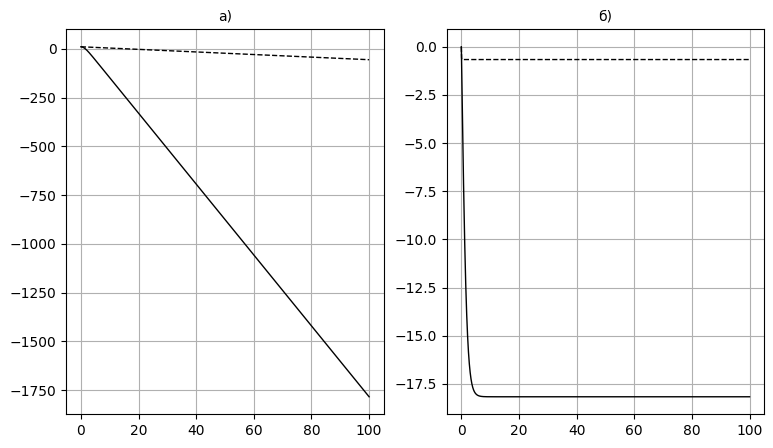

In [ ]:
# Ячейка № 3

# задание значения ускорения
# свободного падения, м/с^2
g = 9.8

# задание значений скоростей v1, v2
v1_1 = 960
v1 = v1_1

v2_1 = 18
v2 = v2_1

# задание значения начальной координаты
y0 = 10

# задание значения начальной скорости
v0 = 0

# задание границ временного интервала
# для нахождения численного решения (3.44)
a = 0
b = 100

# задание шага интегрирования (3.44)
step = 0.01

# вызов функции, возвращающей
# численное решение системы ОДУ (3.44)
a_sol = solve_ivp(Friction, [a, b], [y0, v0], max_step=step)

# вычисление численных решений ОДУ (3.44) для
# следующих значений скорости
v1_2 = 17
v1 = v1_2

v2_2 = 0.65
v2 = v2_2

# вызов функции, возвращающей
# численное решение системы ОДУ (3.44)
a_sol2 = solve_ivp(Friction, [a, b], [y0, v0], max_step=step)

# визуализация зависимостей x=x(t)
fig = plt.figure(figsize=(9, 5))
ax = plt.subplot(1, 2, 1)
ax.plot(a_sol.t[:], a_sol.y[0, :], "-k", lw=1)
ax.plot(a_sol2.t[:], a_sol2.y[0, :], "--k", lw=1)
ax.grid(True)
ax.set_title("а)", fontsize=10)

# визуализация зависимостей vy=vy(t)
ax = plt.subplot(1, 2, 2)
ax.plot(a_sol.t[:], a_sol.y[1, :], "-k", lw=1)
ax.plot(a_sol2.t[:], a_sol2.y[1, :], "--k", lw=1)
ax.grid(True)
ax.set_title("б)", fontsize=10)

plt.show()

In [ ]:
# Ячейка № 4

# печать значения скорости v1
print("v1 = ", v1_1)

# печать значения скорости v2
print("v2 = ", v2_1, "\n")

# вычисление максимального
# значения скорости в соответствие с (3.37), (3.32)
V_max_analyt = -(v2_1**2) / (2 * v1_1) * (np.sqrt(1 + 4 * v1_1**2 / v2_1**2) + 1)
print("V_max_analyt = ", V_max_analyt)

# вычисление максимального
# значения скорости на основе
# численного решения СДУ (3.44)
V_max_digit = np.min(a_sol.y[1, :])
print("V_max_digit = ", V_max_digit, "\n")

# вычисление относительной погрешности
# значения V_max_digit
err = (V_max_analyt - V_max_digit) / V_max_analyt * 100
print("Error = ", err, "%")

print("--------------------------------------")
# печать заданного скорости v1
print("v1 = ", v1_2)

# печать значения скорости v2
print("v2 = ", v2_2, "\n")

# вычисление максимального
# значения скорости в соответствие с (3.37), (3.32)
V_max_analyt2 = -(v2_2**2) / (2 * v1_2) * (np.sqrt(1 + 4 * v1_2**2 / v2_2**2) + 1)
print("V_max_analyt = ", V_max_analyt2)

# вычисление максимального
# значения скорости на основе
# численного решения СДУ (3.44)
V_max_digit2 = np.min(a_sol2.y[1, :])
print("V_max_digit2 = ", V_max_digit2, "\n")

# вычисление относительной погрешности
# значения v_max_digit
err = (V_max_analyt2 - V_max_digit2) / V_max_analyt2 * 100
print("Error = ", err, "%")

v1 =  960
v2 =  18 

V_max_analyt =  -18.16954099824505
V_max_digit =  -18.16954099824489 

Error =  8.798907774360628e-13 %
--------------------------------------
v1 =  17
v2 =  0.65 

V_max_analyt =  -0.6625452421763817
V_max_digit2 =  -0.6625452421763814 

Error =  3.351387811580103e-14 %
